<a href="https://colab.research.google.com/github/sakethyalamanchili/SimpleML-Projects/blob/main/Dense_Network_for_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dense Network for Image Classification

## Importing all the necessary libraries

In [14]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import KFold
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from google.colab import files

## Set a seed for reproducability

In [15]:
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

## Unzip the file

In [16]:
!pip install -q gdown

In [17]:
file_id = '1Gg3YRkJ7pcJJD5veAh7B6x2AxQoCqCNG'
zip_file = 'dogvscat1000.zip'

if not os.path.exists(zip_file):
  print(f"Downloading {zip_file}...")
  !gdown --id {file_id} -O {zip_file}
  print("Download complete!")
else:
  print(f"{zip_file} already exists.")

dogvscat1000.zip already exists.


In [18]:
if not os.path.exists('dogvscat1000'):
    print(f"Unzipping {zip_file}...")
    !unzip -q {zip_file}
    print("Unzipping done!")
else:
    print("Files already unzipped.")

Files already unzipped.


In [19]:
data_dir = 'dogvscat1000/'
all_files = os.listdir(data_dir)
print(all_files[:5])

['cat.211.jpg', 'dog.248.jpg', 'dog.98.jpg', 'dog.154.jpg', 'cat.458.jpg']


## Display Random Images

In [20]:
def display_random_class_images(directory, animal_class, num_images):
  """
  Displays a specified number of random images for a chosen class ('cat' or 'dog').
  """
  if animal_class not in ['cat', 'dog']:
    print("Error: Please choose either 'cat' or 'dog'.")
    return

  # Filter the list to get only the chosen class
  all_files = os.listdir(directory)
  class_files = [f for f in all_files if f.startswith(animal_class)]

  if not class_files:
    print(f"No images found for class: {animal_class}")

  num_images = min(num_images, len(class_files))
  random_indices = np.random.choice(len(class_files), num_images, replace=False)

  plt.figure(figsize=(12, 8))
  for i, idx in enumerate(random_indices):
    if num_images <= 4:
      rows, cols = 1, num_images
    else:
      rows, cols = 2, (num_images + 1) // 2

    plt.subplot(rows, cols, i+1)
    filename = class_files[idx]
    img = load_img(os.path.join(directory, filename))
    plt.imshow(img)
    plt.axis('off')
    plt.title(filename)

  plt.tight_layout()
  plt.show()

Showing 4 random CAT images ... 


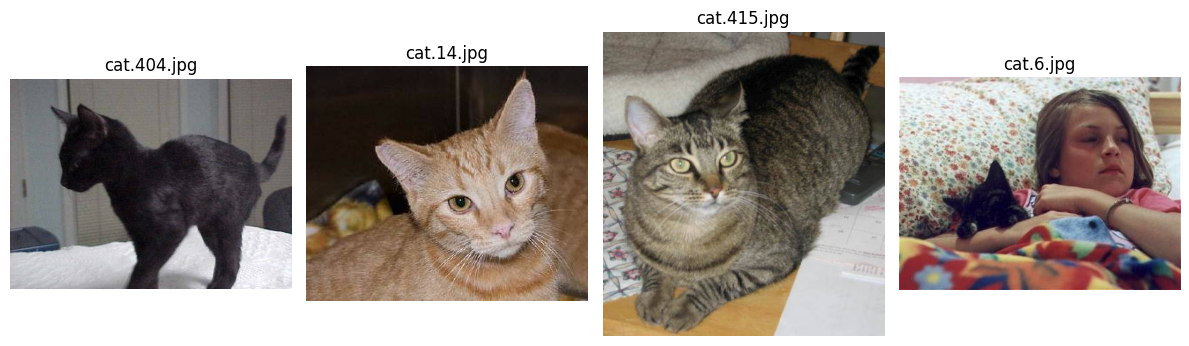

In [21]:
print("Showing 4 random CAT images ... ")
display_random_class_images(data_dir, 'cat', 4)

Showing 6 random DOG images ... 


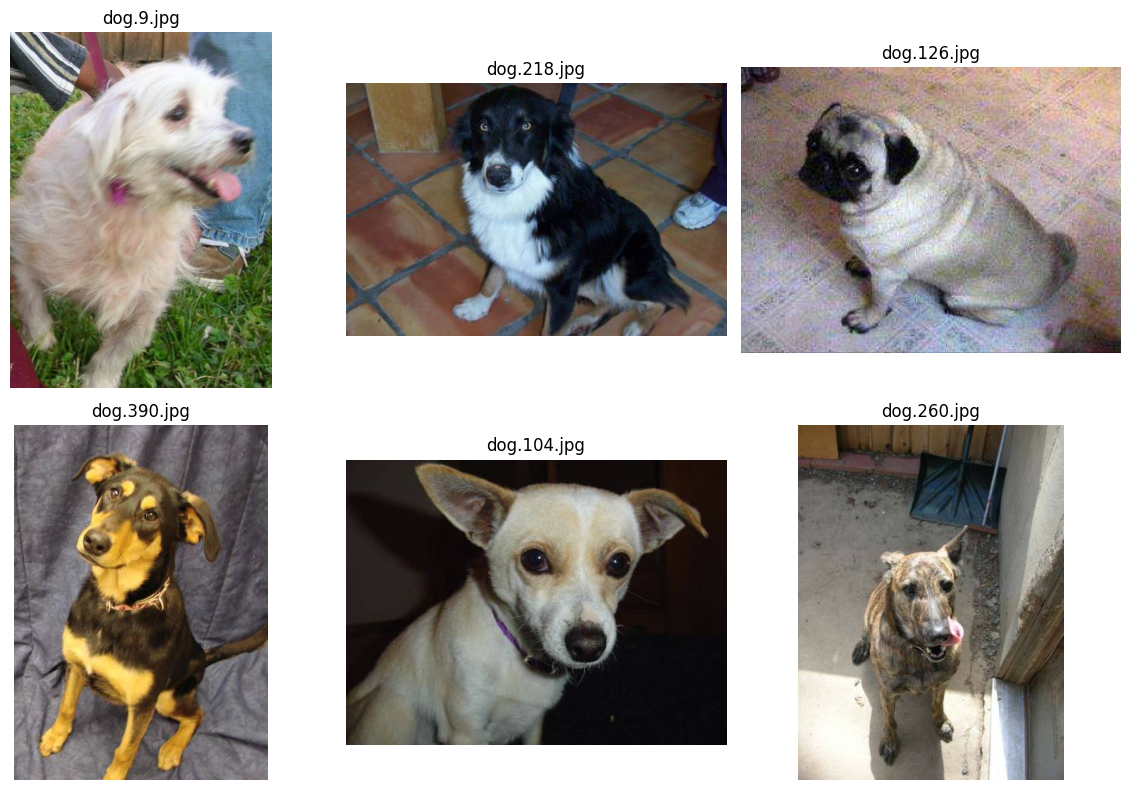

In [22]:
print("Showing 6 random DOG images ... ")
display_random_class_images(data_dir, 'dog', 6)

## Data Preparation

In [23]:
img_size = (64, 64)

cat_files = [f for f in all_files if f.startswith('cat')][:500]
dog_files = [f for f in all_files if f.startswith('dog')][:500]
filepaths = [os.path.join(data_dir, f) for f in cat_files + dog_files]
labels = [0] * len(cat_files) + [1] * len(dog_files) # 0 for Cat, 1 for Dog

images = []
for path in filepaths:
  img = load_img(path, target_size=img_size, color_mode='rgb')
  img_array = img_to_array(img) / 255.0
  images.append(img_array)

X_data = np.array(images)
X_data_flattened = X_data.reshape(X_data.shape[0], -1) # Flatten (64, 64) -> 4096
y_data = to_categorical(np.array(labels)) # One-Hot Encode Labels

print(f"Data prepared successfully. Input data shape: {X_data_flattened.shape}\n")

Data prepared successfully. Input data shape: (1000, 12288)



> Note: Flatten is a very common preprocessing step in machine learning. Many classical algorithms, like Logistic Regression, Support Vector Machines (SVMs), and basic fully-connected neural networks, expect input data as a 2D matrix with the shape `(number_of_samples, number_of_features)`.

> This line of code converts data (like images, which are 3D or 4D arrays) into that required 2D format, making it ready to be fed into a model.

## Baseline Model

EVALUATING BASELINE MODEL ... 

 Training on Fold 1/10 ... 
Accuracy for Fold 1:  50.00%


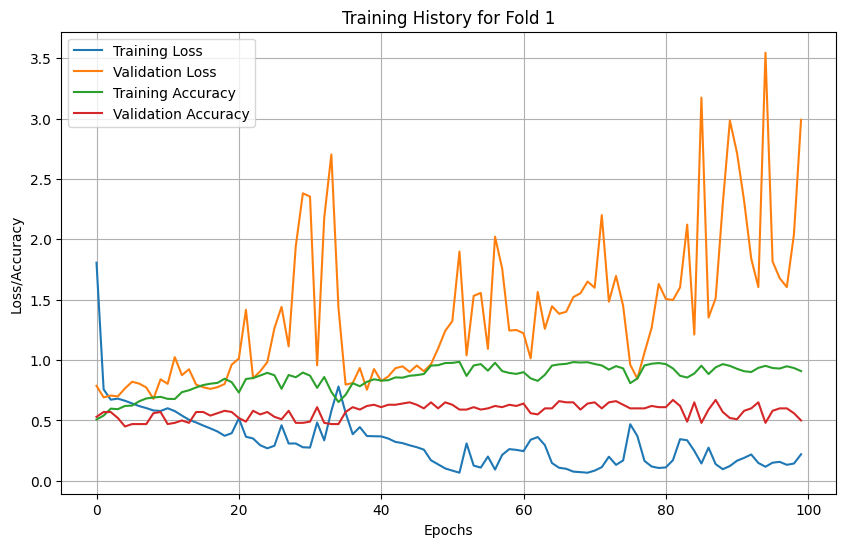


 Training on Fold 2/10 ... 
Accuracy for Fold 2:  58.00%


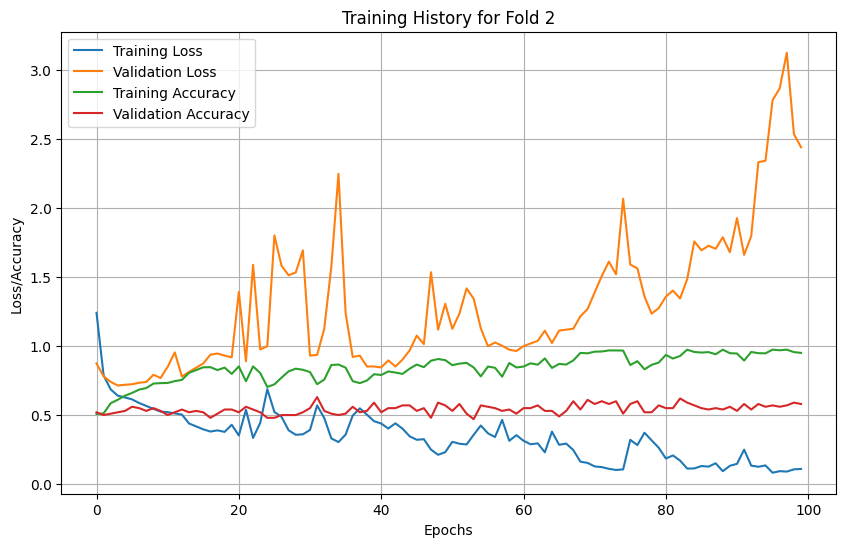


 Training on Fold 3/10 ... 
Accuracy for Fold 3:  51.00%


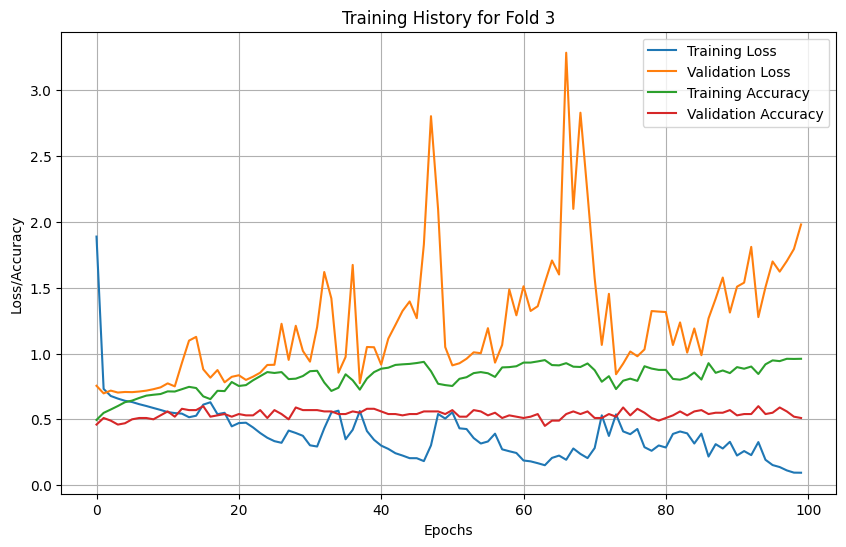


 Training on Fold 4/10 ... 
Accuracy for Fold 4:  54.00%


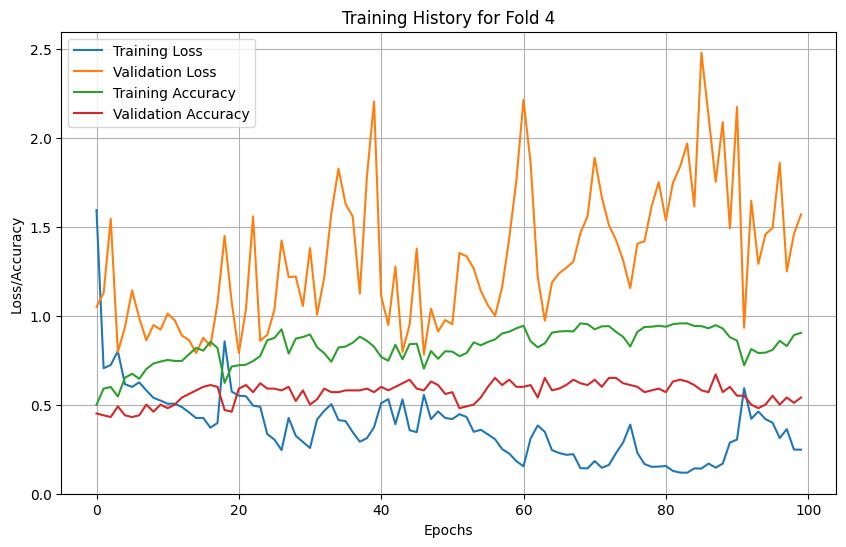


 Training on Fold 5/10 ... 
Accuracy for Fold 5:  49.00%


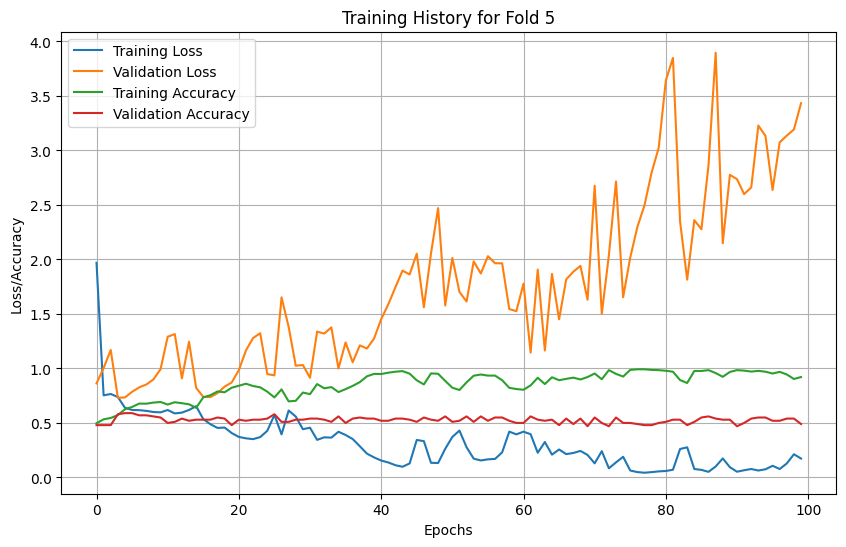


 Training on Fold 6/10 ... 
Accuracy for Fold 6:  51.00%


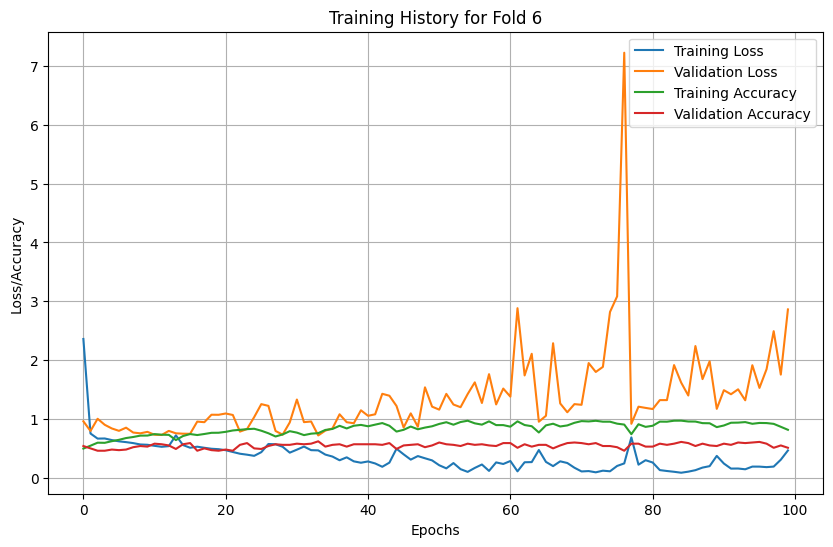


 Training on Fold 7/10 ... 
Accuracy for Fold 7:  53.00%


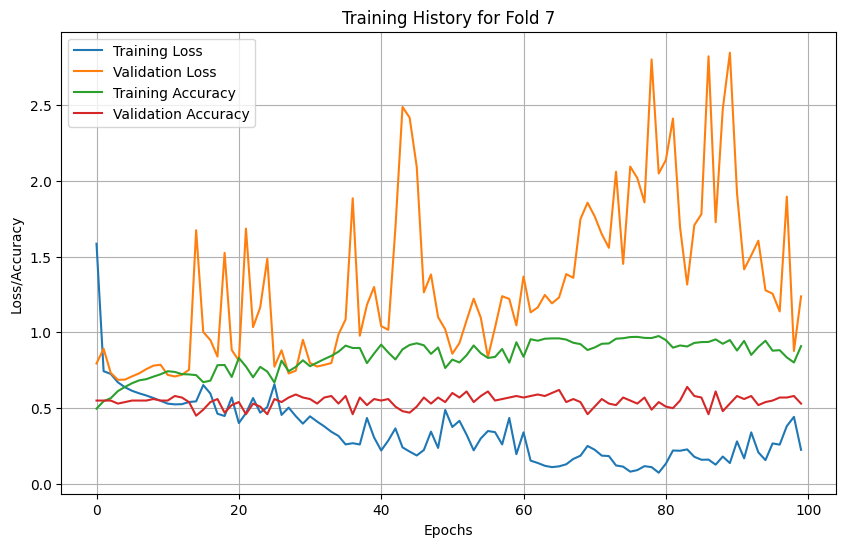


 Training on Fold 8/10 ... 
Accuracy for Fold 8:  62.00%


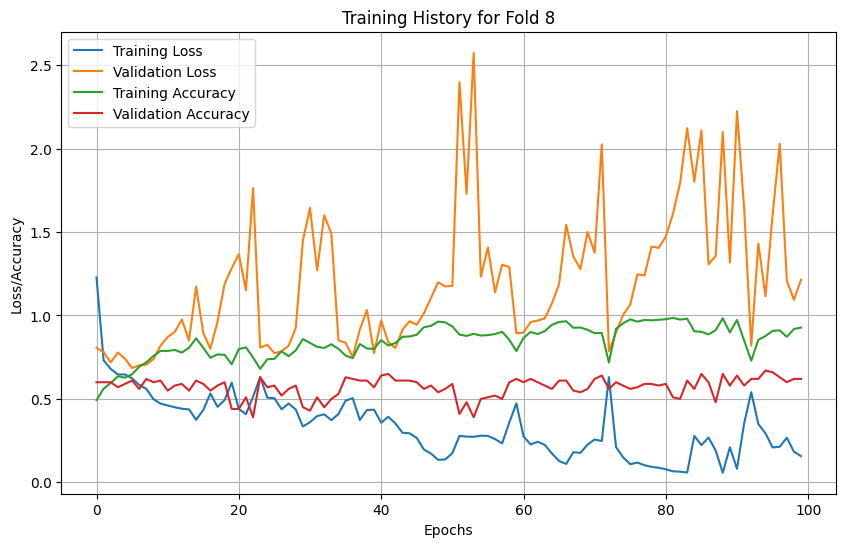


 Training on Fold 9/10 ... 
Accuracy for Fold 9:  63.00%


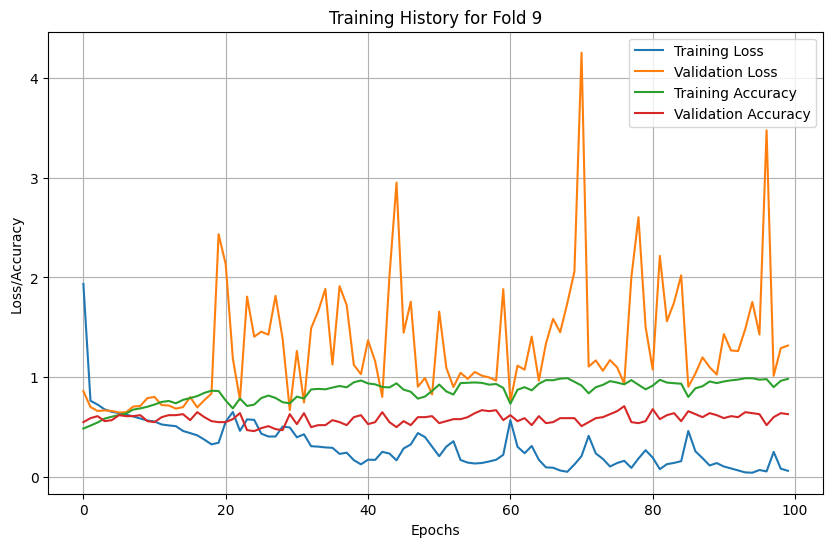


 Training on Fold 10/10 ... 
Accuracy for Fold 10:  60.00%


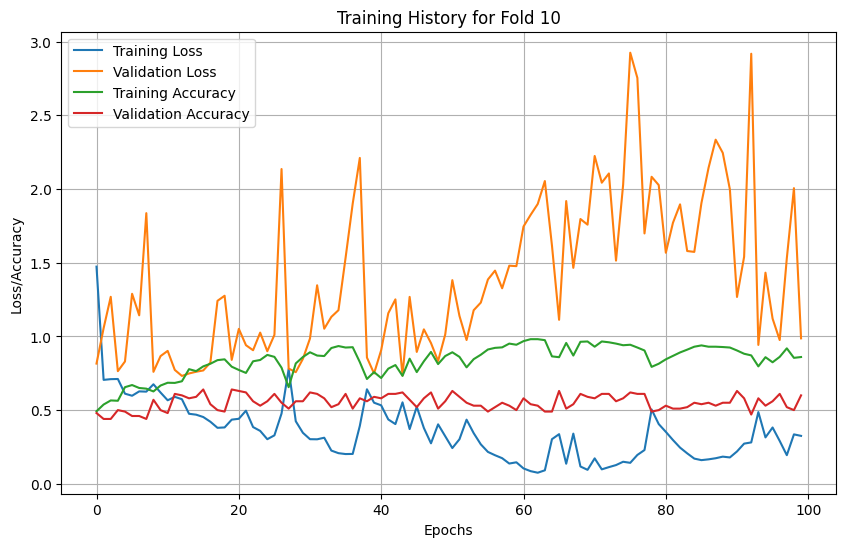


 Cross Validation Results ... 
Mean Accuracy: 55.10%, Std Dev: 4.95%



In [24]:
print("EVALUATING BASELINE MODEL ... ")
kf = KFold(n_splits=10, shuffle=True, random_state=42)
baseline_scores = []

for fold_no, (train_index, test_index) in enumerate(kf.split(X_data_flattened), 1):
  X_train, X_test = X_data_flattened[train_index], X_data_flattened[test_index]
  y_train, y_test = y_data[train_index], y_data[test_index]

  # Define the model sequence
  model_1 = Sequential([
      Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
      Dense(128, activation='relu'),
      Dense(2, activation='softmax')
  ])

  model_1.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

  print(f"\n Training on Fold {fold_no}/10 ... ")

  # Train the Model
  history_1 = model_1.fit(X_train, y_train,
                          validation_data = (X_test, y_test),
                          epochs=100,
                          batch_size=32,
                          verbose=0)

  # Evaluate and store score
  _, accuracy = model_1.evaluate(X_test, y_test, verbose=0)
  baseline_scores.append(accuracy)
  print(f"Accuracy for Fold {fold_no}: {accuracy * 100 : .2f}%")

  # Plotting history for each field
  plt.figure(figsize=(10, 6))
  plt.plot(history_1.history['loss'], label='Training Loss')
  plt.plot(history_1.history['val_loss'], label='Validation Loss')
  plt.plot(history_1.history['accuracy'], label='Training Accuracy')
  plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
  plt.title(f"Training History for Fold {fold_no}")
  plt.xlabel('Epochs')
  plt.ylabel('Loss/Accuracy')
  plt.legend()
  plt.grid(True)
  plt.show()

print("\n Cross Validation Results ... ")
print(f"Mean Accuracy: {np.mean(baseline_scores) * 100:.2f}%, Std Dev: {np.std(baseline_scores) * 100:.2f}%\n")

## Batch Normalization Model

EVALUATING BATCH NORMALIZATION MODEL ... 

 Training on Fold 1/10 ... 
Accuracy for Fold 1:  60.00%


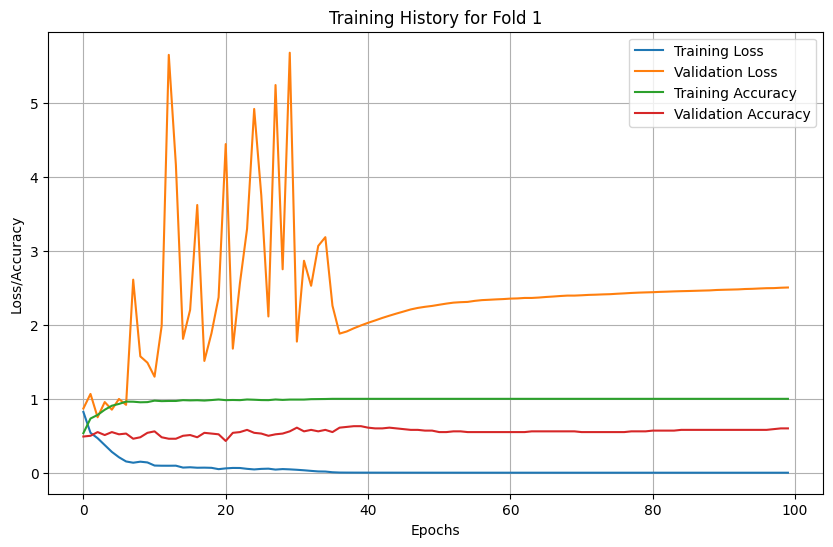


 Training on Fold 2/10 ... 
Accuracy for Fold 2:  55.00%


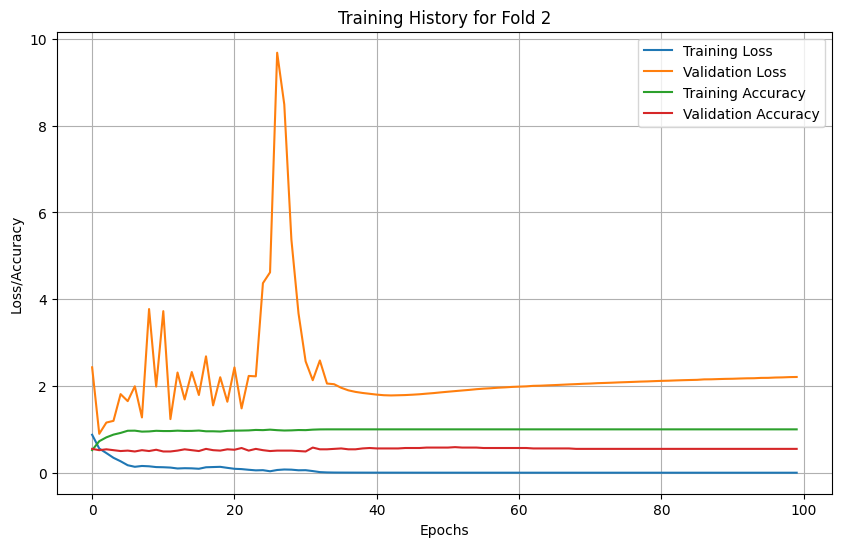


 Training on Fold 3/10 ... 
Accuracy for Fold 3:  53.00%


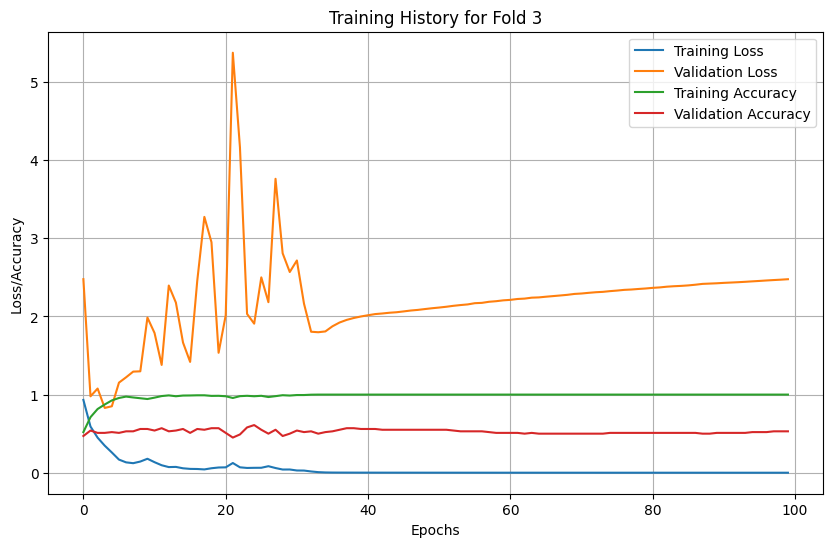


 Training on Fold 4/10 ... 
Accuracy for Fold 4:  60.00%


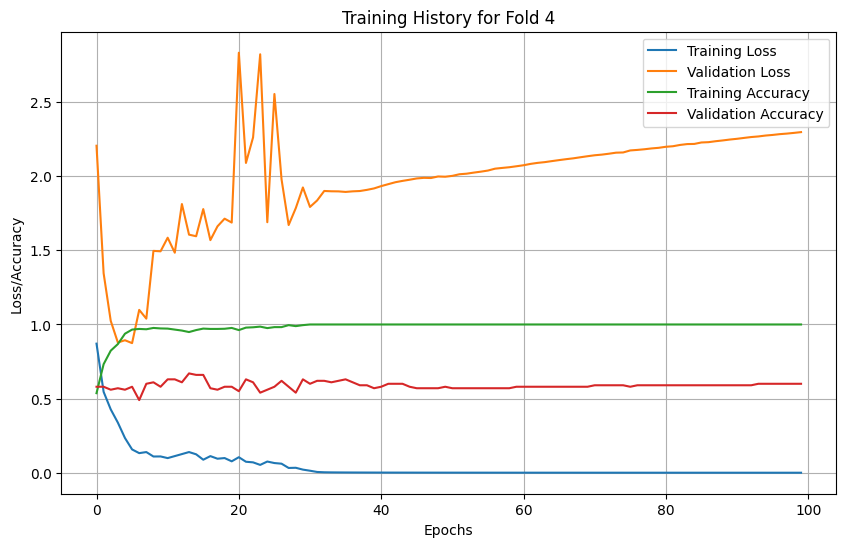


 Training on Fold 5/10 ... 
Accuracy for Fold 5:  59.00%


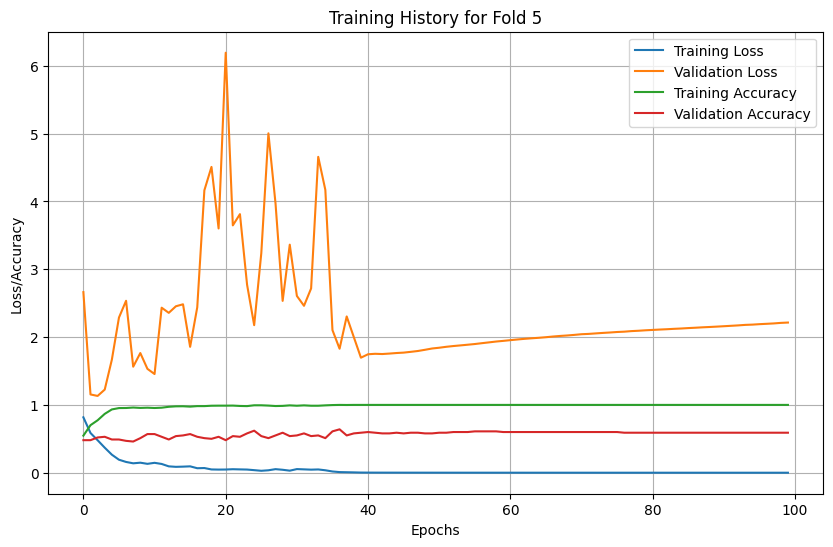


 Training on Fold 6/10 ... 
Accuracy for Fold 6:  67.00%


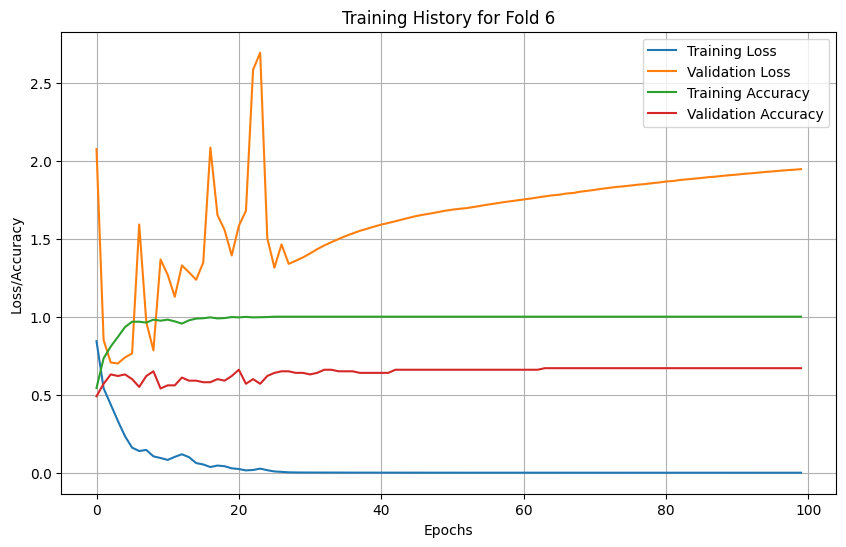


 Training on Fold 7/10 ... 
Accuracy for Fold 7:  56.00%


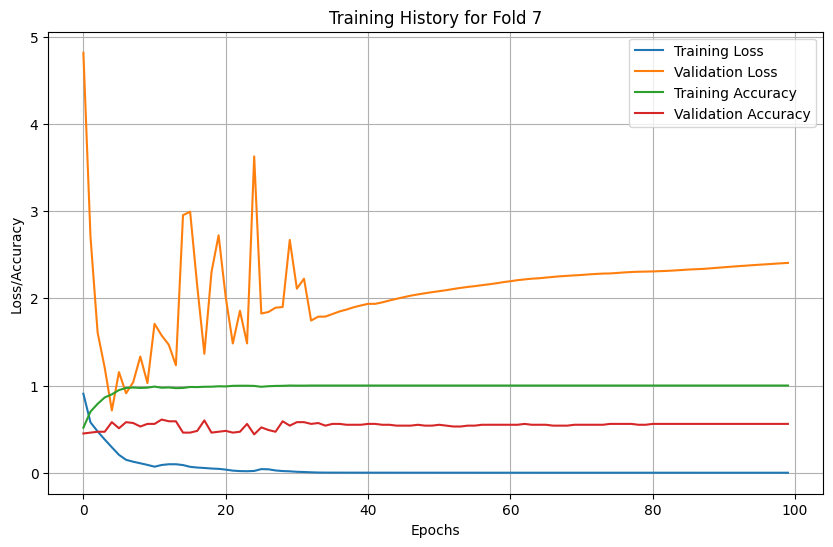


 Training on Fold 8/10 ... 
Accuracy for Fold 8:  45.00%


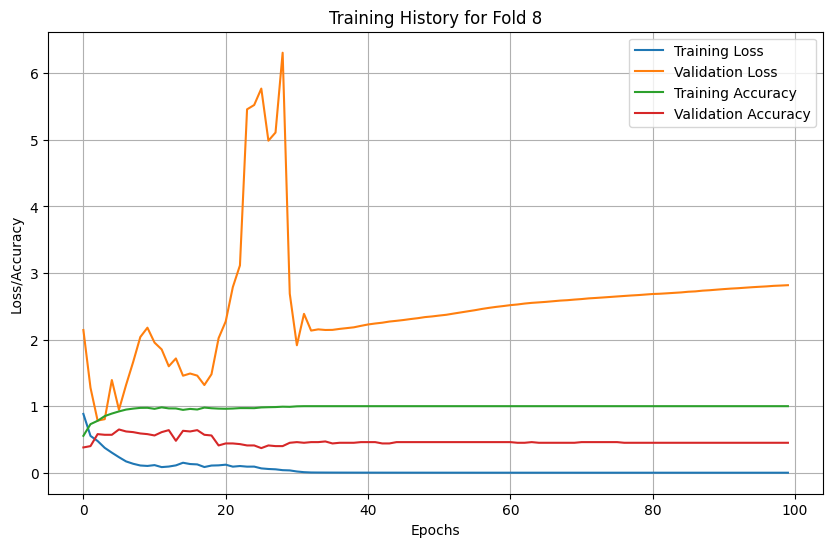


 Training on Fold 9/10 ... 
Accuracy for Fold 9:  68.00%


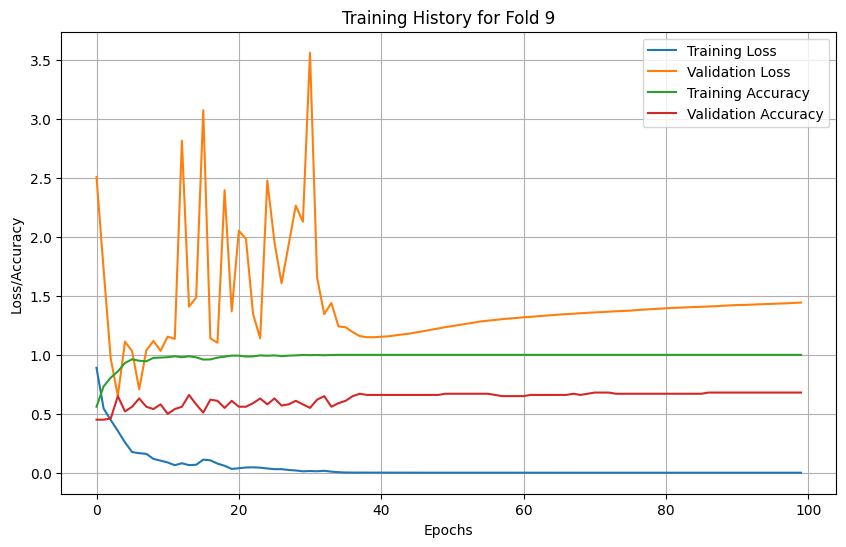


 Training on Fold 10/10 ... 
Accuracy for Fold 10:  58.00%


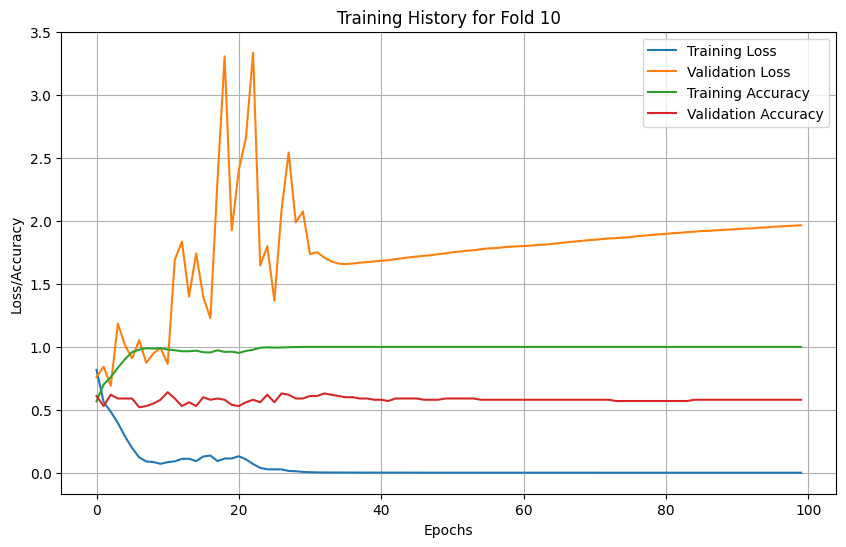


 Cross Validation Results ... 
Mean Accuracy: 58.10%, Std Dev: 6.30%



In [25]:
print("EVALUATING BATCH NORMALIZATION MODEL ... ")
kf = KFold(n_splits=10, shuffle=True, random_state=42)
bn_scores = []

for fold_no, (train_index, test_index) in enumerate(kf.split(X_data_flattened), 1):
  X_train, X_test = X_data_flattened[train_index], X_data_flattened[test_index]
  y_train, y_test = y_data[train_index], y_data[test_index]

  # Define the model sequence
  model_2 = Sequential([
      Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
      BatchNormalization(),
      Dense(128, activation='relu'),
      BatchNormalization(),
      Dense(2, activation='softmax')
  ])

  model_2.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

  print(f"\n Training on Fold {fold_no}/10 ... ")

  # Train the Model
  history_2 = model_2.fit(X_train, y_train,
                          validation_data = (X_test, y_test),
                          epochs=100,
                          batch_size=32,
                          verbose=0)

  # Evaluate and store score
  _, accuracy = model_2.evaluate(X_test, y_test, verbose=0)
  bn_scores.append(accuracy)
  print(f"Accuracy for Fold {fold_no}: {accuracy * 100 : .2f}%")

  # Plotting history for each field
  plt.figure(figsize=(10, 6))
  plt.plot(history_2.history['loss'], label='Training Loss')
  plt.plot(history_2.history['val_loss'], label='Validation Loss')
  plt.plot(history_2.history['accuracy'], label='Training Accuracy')
  plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy')
  plt.title(f"Training History for Fold {fold_no}")
  plt.xlabel('Epochs')
  plt.ylabel('Loss/Accuracy')
  plt.legend()
  plt.grid(True)
  plt.show()

print("\n Cross Validation Results ... ")
print(f"Mean Accuracy: {np.mean(bn_scores) * 100:.2f}%, Std Dev: {np.std(bn_scores) * 100:.2f}%\n")

> Note: Batch normalization is a technique that makes training deep neural networks faster and more stable. For each small batch of data during training, it normalizes the inputs to a layer, making their average 0 and their standard deviation 1. This helps because it keeps the data distribution consistent between layers, preventing the network from having to learn a "moving target" and allowing it to learn more efficiently.

## Dropout Model

EVALUATING DROPOUT MODEL ... 

 Training on Fold 1/10 ... 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy for Fold 1:  52.00%


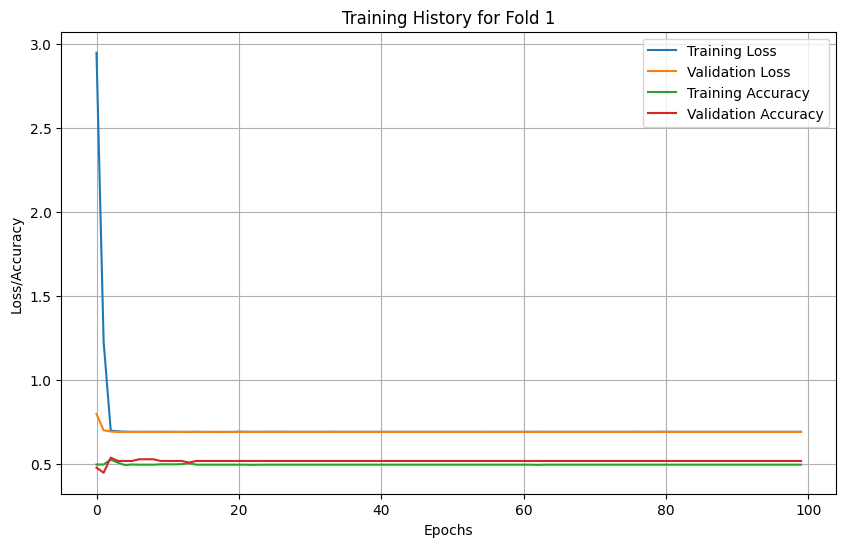


 Training on Fold 2/10 ... 
Accuracy for Fold 2:  52.00%


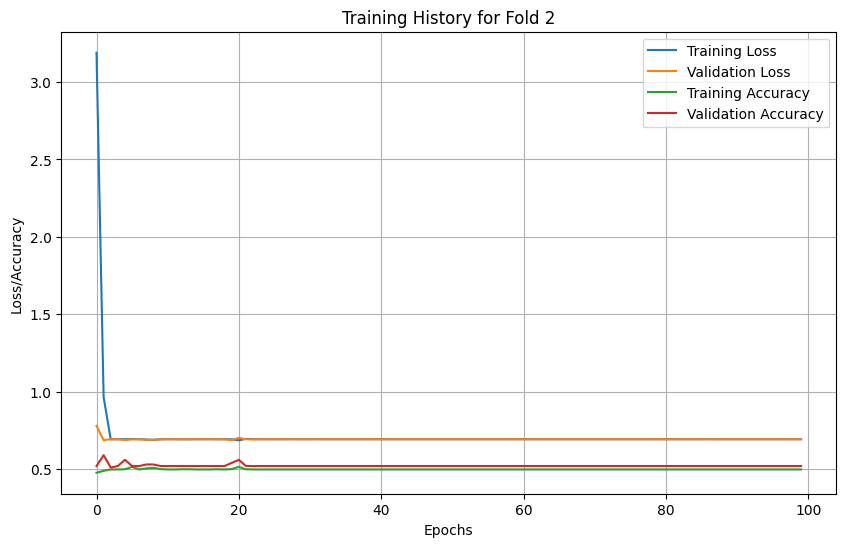


 Training on Fold 3/10 ... 
Accuracy for Fold 3:  46.00%


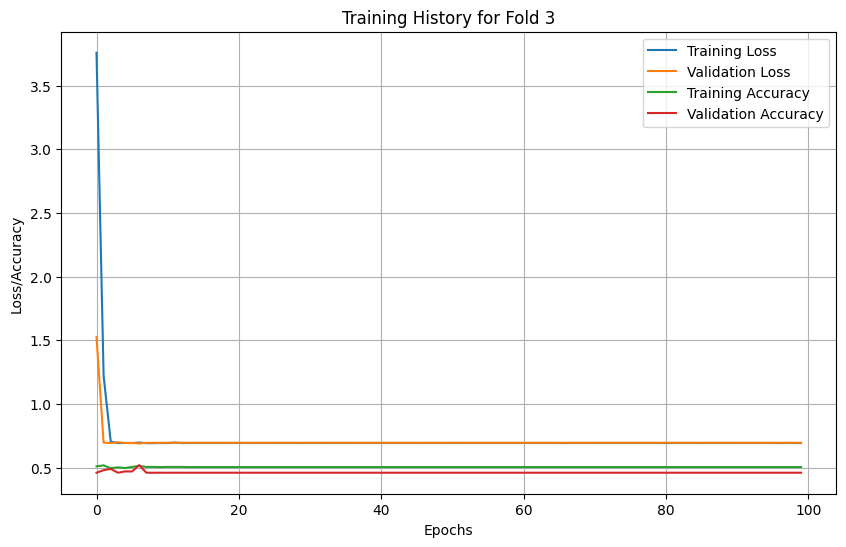


 Training on Fold 4/10 ... 
Accuracy for Fold 4:  42.00%


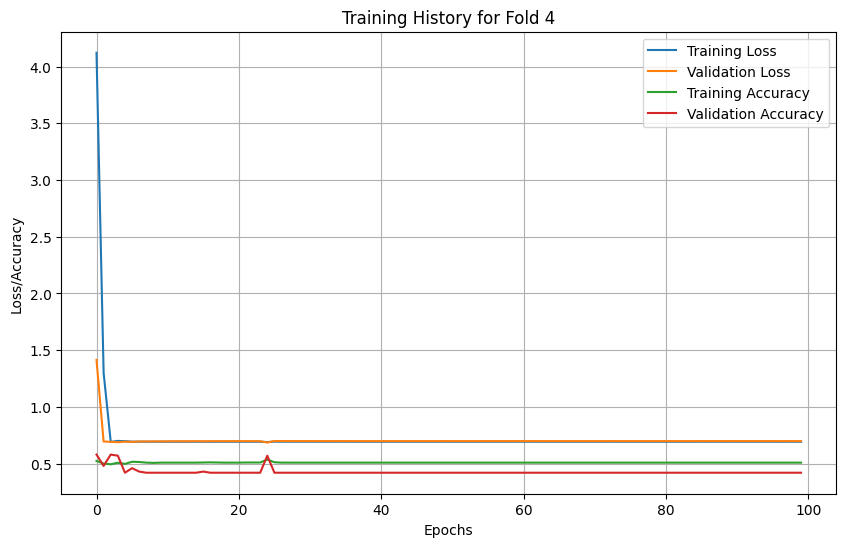


 Training on Fold 5/10 ... 
Accuracy for Fold 5:  48.00%


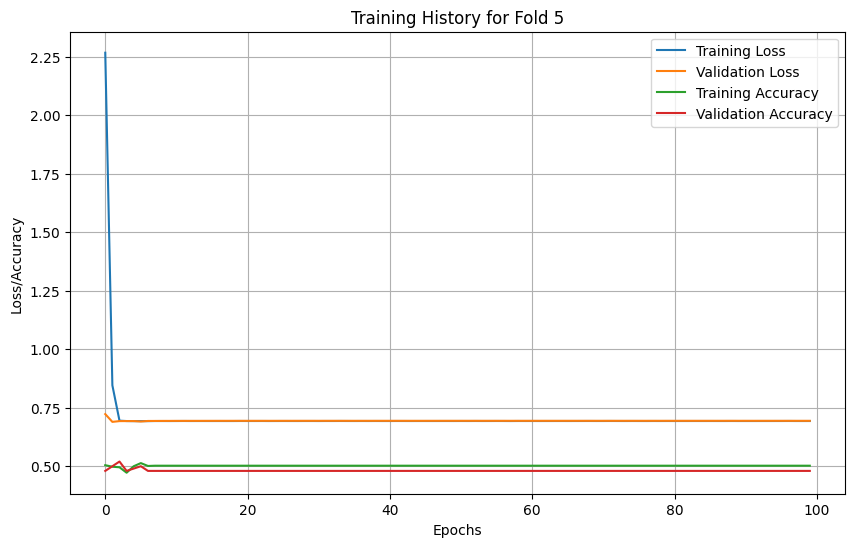


 Training on Fold 6/10 ... 
Accuracy for Fold 6:  46.00%


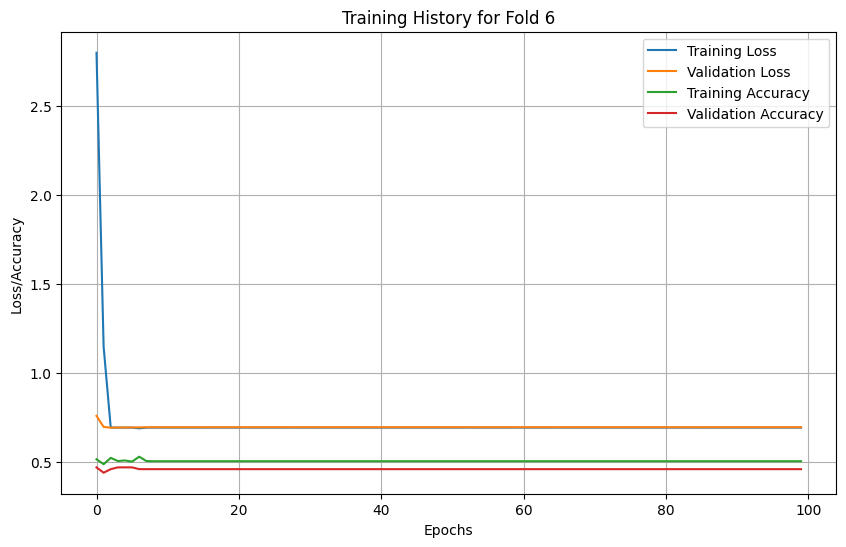


 Training on Fold 7/10 ... 
Accuracy for Fold 7:  55.00%


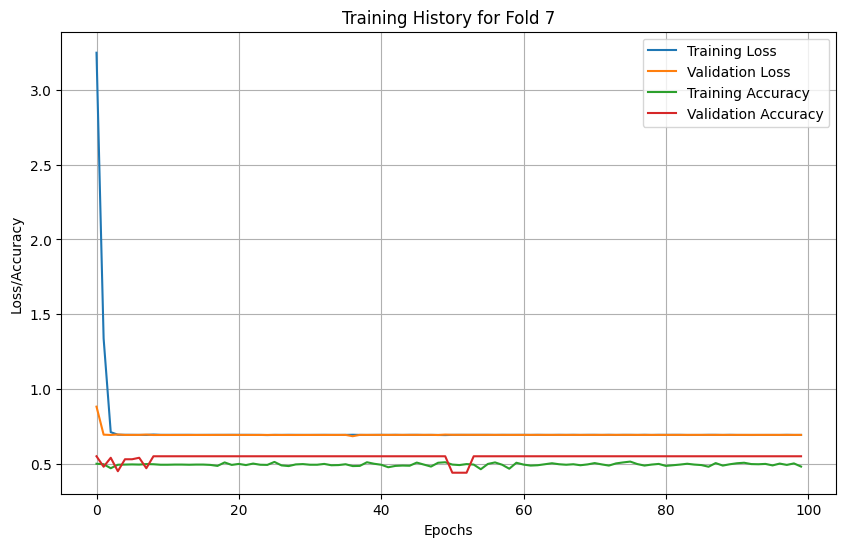


 Training on Fold 8/10 ... 
Accuracy for Fold 8:  40.00%


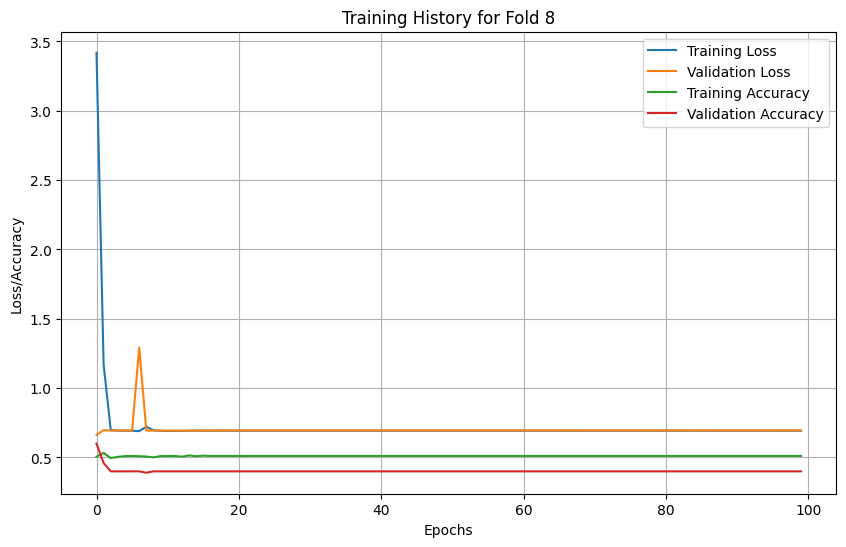


 Training on Fold 9/10 ... 
Accuracy for Fold 9:  56.00%


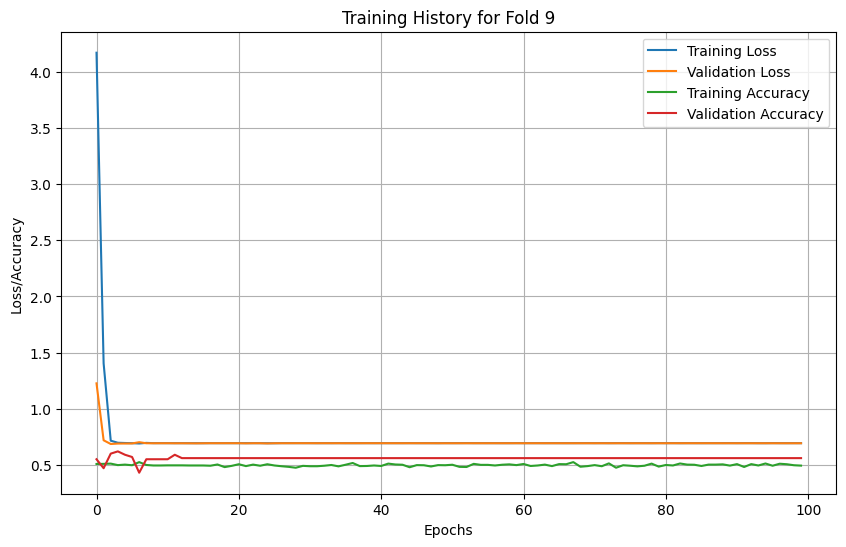


 Training on Fold 10/10 ... 
Accuracy for Fold 10:  44.00%


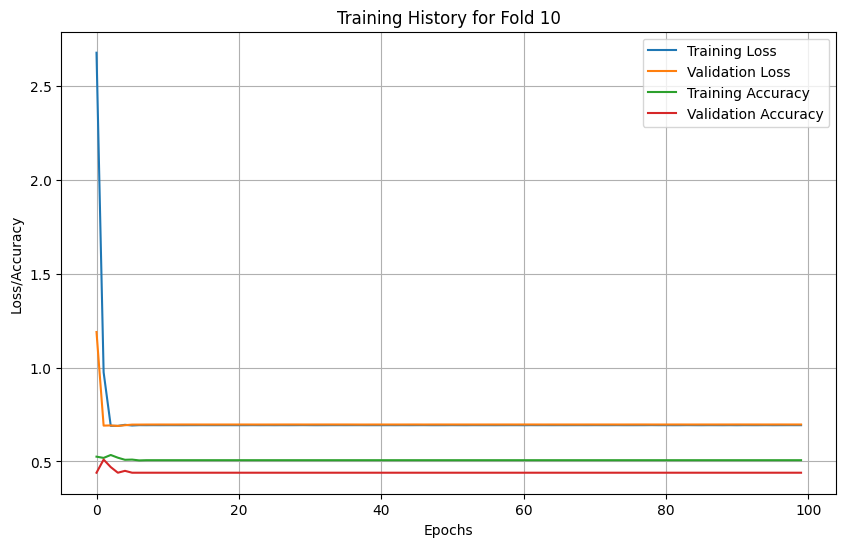


 Cross Validation Results ... 
Mean Accuracy: 48.10%, Std Dev: 5.19%



In [28]:
print("EVALUATING DROPOUT MODEL ... ")
kf = KFold(n_splits=10, shuffle=True, random_state=42)
dropout_scores = []

for fold_no, (train_index, test_index) in enumerate(kf.split(X_data_flattened), 1):
  X_train, X_test = X_data_flattened[train_index], X_data_flattened[test_index]
  y_train, y_test = y_data[train_index], y_data[test_index]

  # Define the model sequence
  model_3 = Sequential([
      Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
      Dropout(0.5),
      Dense(128, activation='relu'),
      Dropout(0.3),
      Dense(2, activation='softmax')
  ])

  model_3.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

  print(f"\n Training on Fold {fold_no}/10 ... ")

  # Train the Model
  history_3 = model_3.fit(X_train, y_train,
                          validation_data = (X_test, y_test),
                          epochs=100,
                          batch_size=32,
                          verbose=0)

  # Evaluate and store score
  _, accuracy = model_3.evaluate(X_test, y_test, verbose=0)
  dropout_scores.append(accuracy)
  print(f"Accuracy for Fold {fold_no}: {accuracy * 100 : .2f}%")

  # Plotting history for each field
  plt.figure(figsize=(10, 6))
  plt.plot(history_3.history['loss'], label='Training Loss')
  plt.plot(history_3.history['val_loss'], label='Validation Loss')
  plt.plot(history_3.history['accuracy'], label='Training Accuracy')
  plt.plot(history_3.history['val_accuracy'], label='Validation Accuracy')
  plt.title(f"Training History for Fold {fold_no}")
  plt.xlabel('Epochs')
  plt.ylabel('Loss/Accuracy')
  plt.legend()
  plt.grid(True)
  plt.show()

print("\n Cross Validation Results ... ")
print(f"Mean Accuracy: {np.mean(dropout_scores) * 100:.2f}%, Std Dev: {np.std(dropout_scores) * 100:.2f}%\n")

> Note: Dropout is a regularization technique for neural networks that helps prevent overfitting. It works by randomly "dropping out" (ignoring) a fraction of neurons during each training step.

## Choosing the Best Model Out of 3

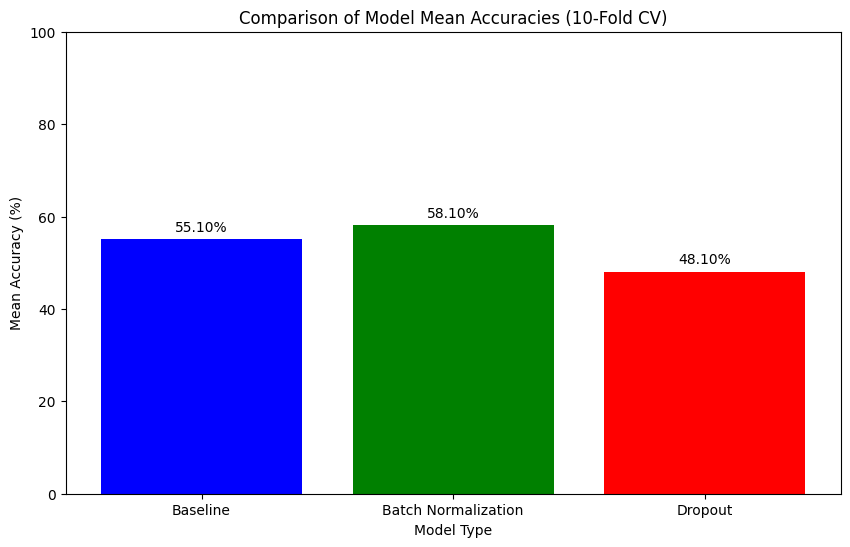

In [29]:
mean_acc_baseline = np.mean(baseline_scores) * 100
mean_acc_bn = np.mean(bn_scores) * 100
mean_acc_dropout = np.mean(dropout_scores) * 100

model_names = ['Baseline', 'Batch Normalization', 'Dropout']
mean_accuracies = [mean_acc_baseline, mean_acc_bn, mean_acc_dropout]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, mean_accuracies, color=['blue', 'green', 'red'])
plt.xlabel('Model Type')
plt.ylabel('Mean Accuracy (%)')
plt.title('Comparison of Model Mean Accuracies (10-Fold CV)')
plt.ylim(0, 100)

for bar in bars:
  yval = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.2f}%',
           ha='center', va='bottom')

plt.show()

## Download the Best Model Out of 3

In [30]:
filename = 'my_best_model.keras'
model_2.save(filename)

print(f"\nModel saved successfully to '{filename}'!")


Model saved successfully to 'my_best_model.keras'!


## Predicting the Output of a Custom Image using the saved model

Predicting the Output of a Custom Image ... 


Saving Screenshot 2025-09-25 134252.png to Screenshot 2025-09-25 134252.png
User uploaded file 'Screenshot 2025-09-25 134252.png' with length 680863 bytes
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step


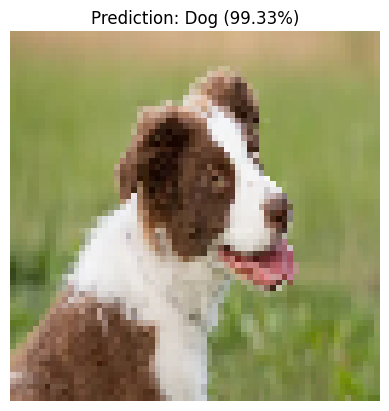

In [31]:
print("Predicting the Output of a Custom Image ... ")

uploaded = files.upload()

for fn in uploaded.keys():
  print(f"User uploaded file '{fn}' with length {len(uploaded[fn])} bytes")

  path = fn
  img = load_img(path, target_size=img_size, color_mode='rgb')
  img_array = img_to_array(img) / 255.0
  img_flattened = img_array.reshape(1, -1) # Reshape for a single prediction
  best_model = tf.keras.models.load_model(filename)
  prediction = best_model.predict(img_flattened)
  predicted_class_index = np.argmax(prediction)
  class_labels = ['Cat', 'Dog']
  predicted_class_label = class_labels[predicted_class_index]
  confidence = np.max(prediction) * 100
  plt.imshow(img)
  plt.title(f"Prediction: {predicted_class_label} ({confidence:.2f}%)")
  plt.axis('off')
  plt.show()

## Analysis of Model Performance

Based on the 10-fold cross-validation results, the **Model with Batch Normalization is the best-performing model**.

### 1. Model with Batch Normalization (The Best Model 🏆)
* **Performance**: **58.10% Mean Accuracy** / 6.30% Std Dev
* **Analysis**: This model achieved the highest accuracy by a notable margin. Image data, especially in color, contains a high degree of complexity. **Batch Normalization** helps by stabilizing the learning process; it normalizes the inputs to each layer, which prevents the model from being overwhelmed by the variance in the data. This stability allowed it to learn more effectively and achieve a better result.

### 2. Baseline Model
* **Performance**: **55.10% Mean Accuracy** / 4.95% Std Dev
* **Why it was not the best**: The baseline model still performed well. However, without the stabilizing effect of batch normalization, it struggled to learn as efficiently from the complex data, resulting in lower overall accuracy. It did have the lowest standard deviation, indicating it was the most consistent, even if not the most accurate.

### 3. Dropout Model
* **Performance**: **48.10% Mean Accuracy** / 5.19% Std Dev
* **Why it was not the best**: This model performed the worst. **Dropout** is a regularization technique designed to prevent **overfitting**, which happens when a model is too complex and starts to memorize the training data. In this case, our simple feedforward network was actually **underfitting**—it was struggling to learn the general patterns in the first place. Adding dropout made this problem even worse by randomly "turning off" parts of the network during training, hindering its ability to learn.

## Conclusion: Impact of Batch Normalization and Dropout

For this specific task, the impact of these layers was very clear:

* **Batch Normalization**: Had a **significant positive impact**. The complexity of the image data created a scenario where its stabilizing effect was highly beneficial, allowing the model to train more effectively and achieve the highest accuracy.
* **Dropout**: Had a **negative impact**. It severely harmed the model's ability to learn, confirming that the network's main challenge was underfitting the data, not overfitting it.